
# Wine Quality - Exploratory Data Analysis

Dataset utilizado para predecir la calidad del vino tinto.

**Target:** `quality`


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

TARGET = "quality"

df = pd.read_csv("../data/raw/winequality-red.csv")

print(df.shape)

df.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Dataset Overview

In [4]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

Shape:
(1599, 12)

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Data Types:


fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


## Missing Values


In [5]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": df.isnull().mean() * 100
})

missing.sort_values(
    by="missing_count",
    ascending=False
)

,missing_count,missing_pct
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


## Descriptive Statistics

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


## Target Distribution

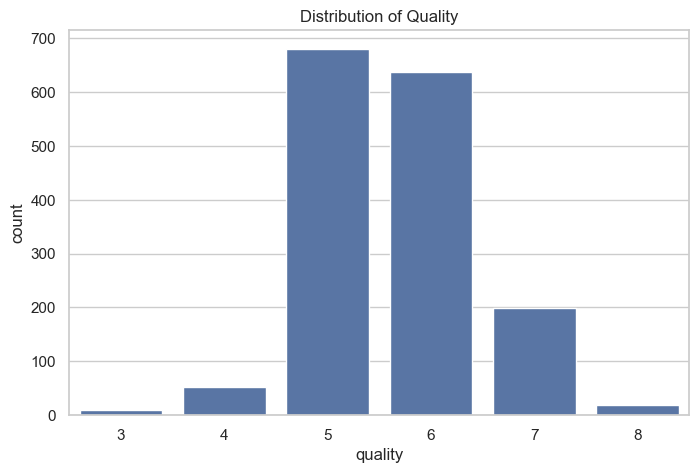

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Distribution of Quality")
plt.show()

## Feature Distributions

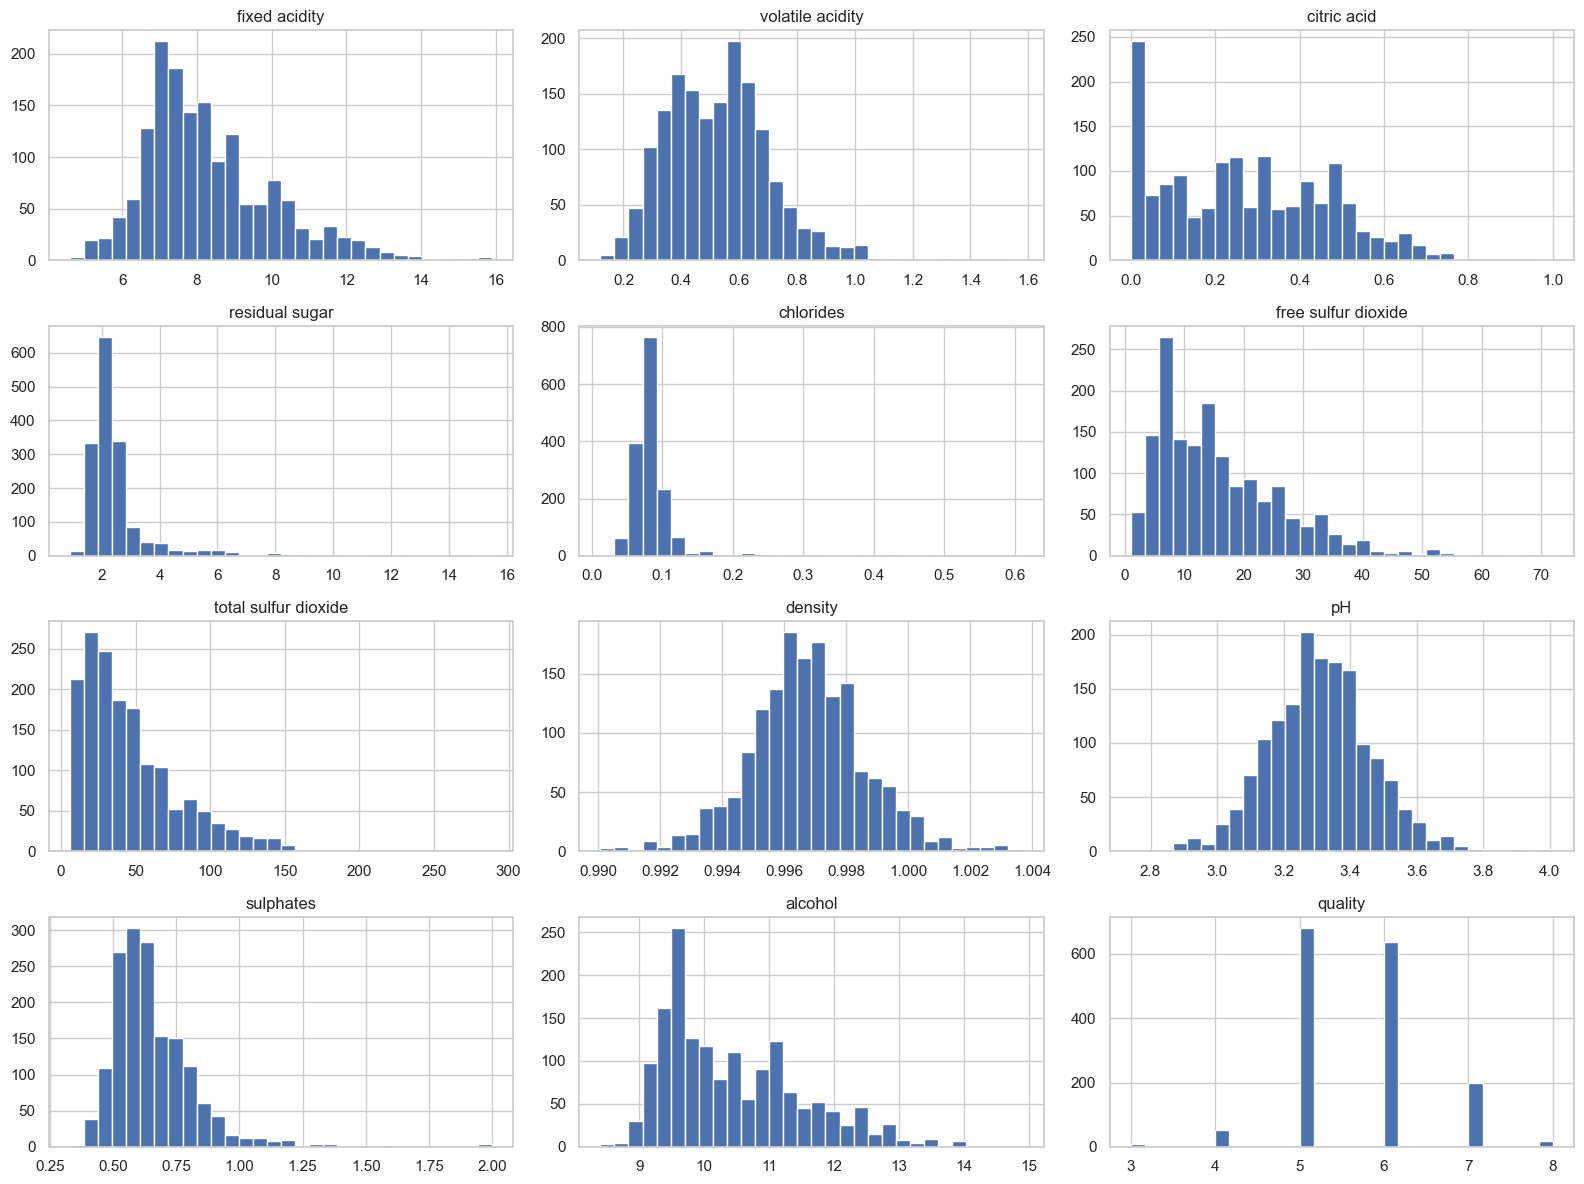

In [8]:
df.hist(
    figsize=(16,12),
    bins=30
)

plt.tight_layout()
plt.show()

## Correlation Matrix

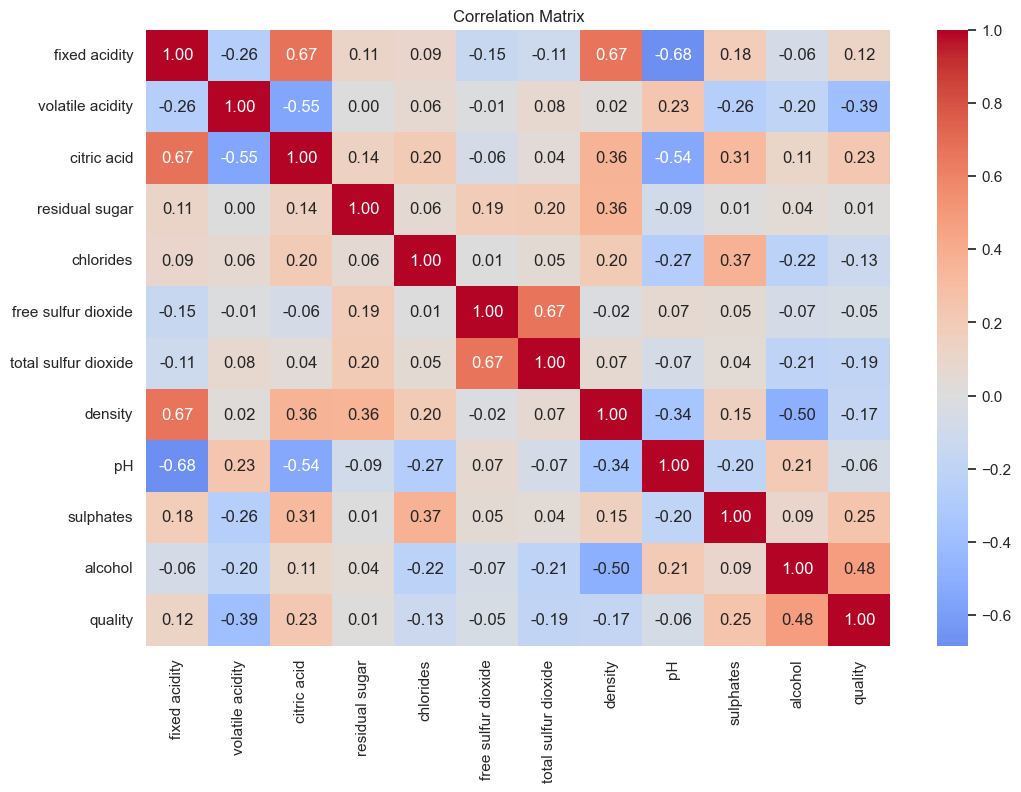

In [15]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## Correlation with Target

In [10]:
target_corr = (
    corr[TARGET]
    .sort_values(ascending=False)
)

target_corr

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

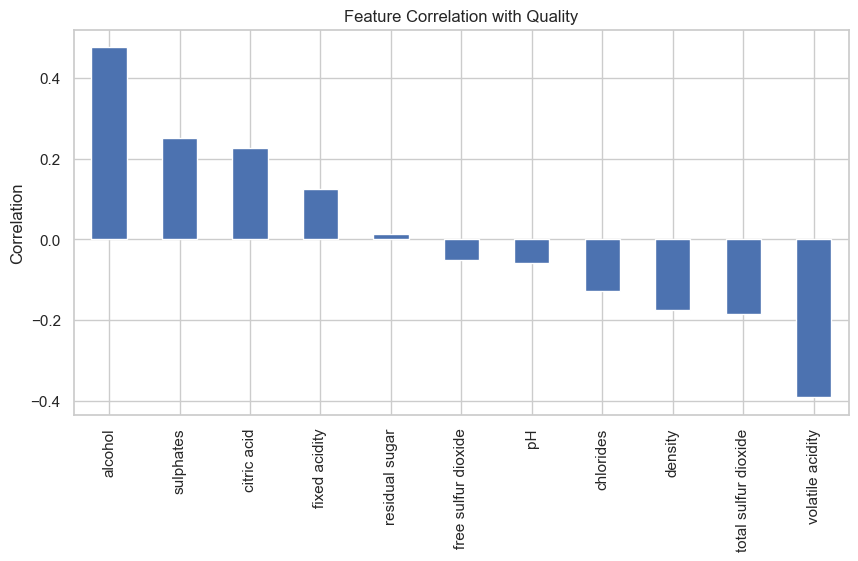

In [11]:
plt.figure(figsize=(10,5))

target_corr.drop(TARGET).plot(
    kind="bar"
)

plt.title("Feature Correlation with Quality")
plt.ylabel("Correlation")

plt.show()

## Top Features vs Target

In [12]:
top_features = (
    target_corr
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top_features

Index(['alcohol', 'volatile acidity', 'sulphates', 'citric acid',
       'total sulfur dioxide'],
      dtype='str')

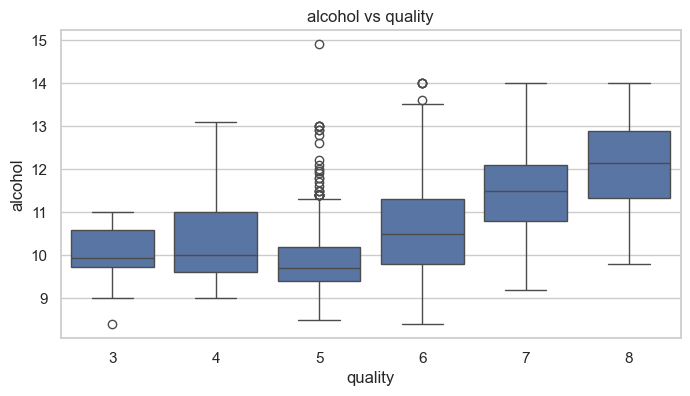

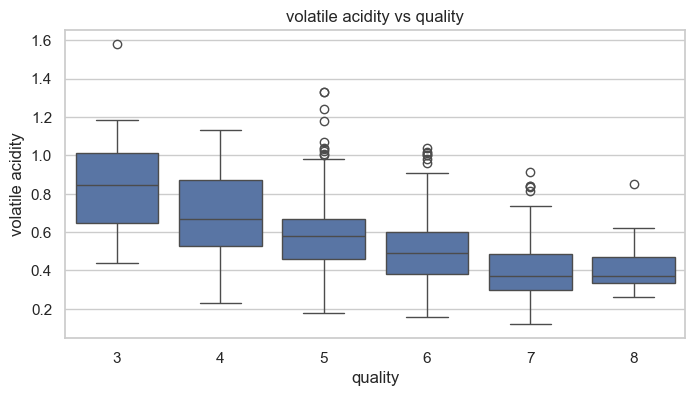

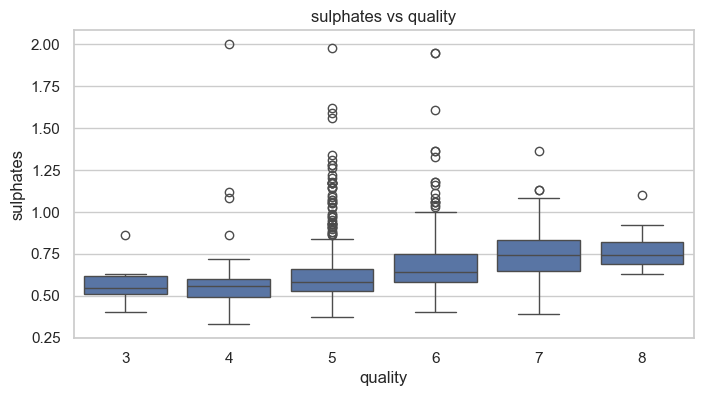

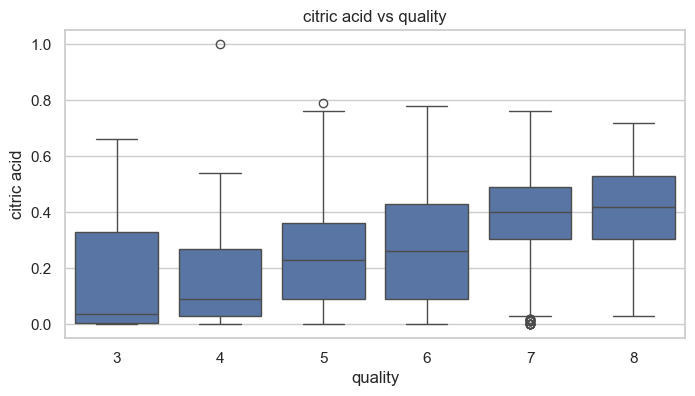

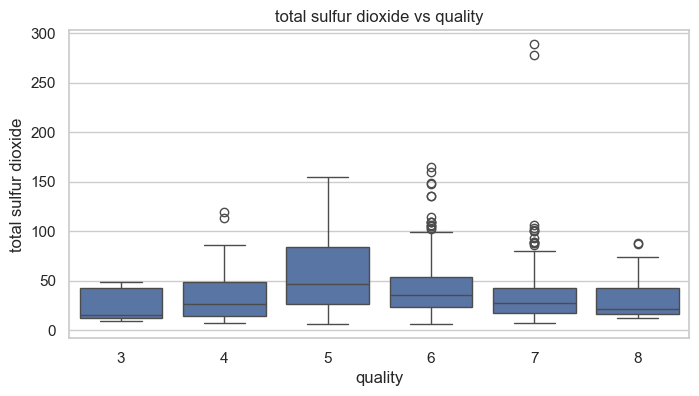

In [13]:
for feature in top_features:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=df,
        x=TARGET,
        y=feature
    )

    plt.title(f"{feature} vs {TARGET}")

    plt.show()

## Outlier Analysis

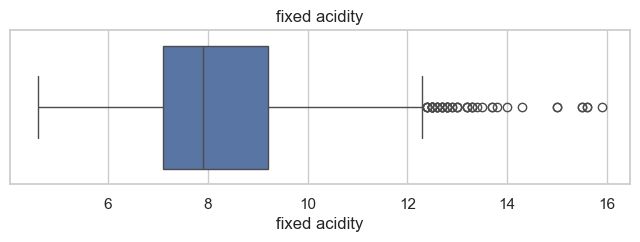

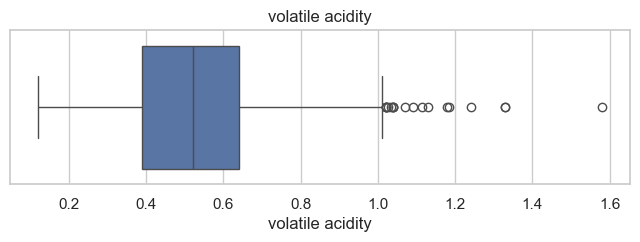

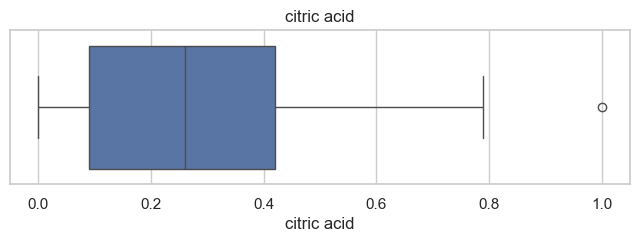

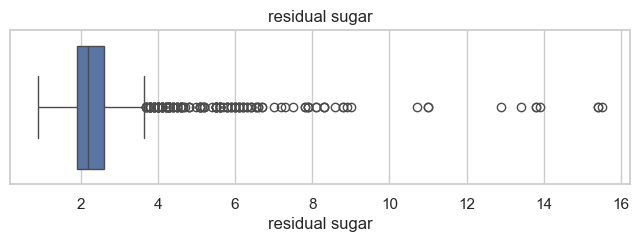

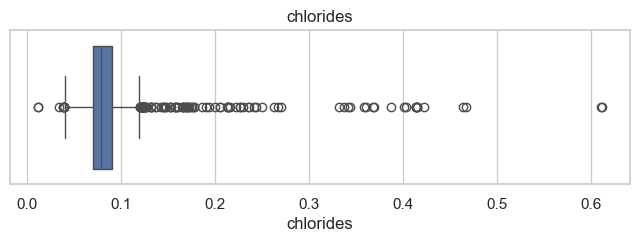

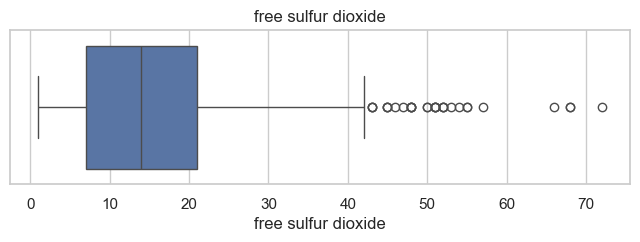

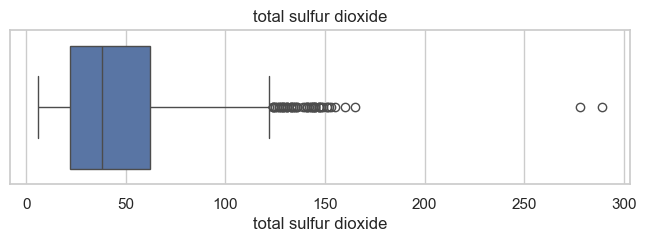

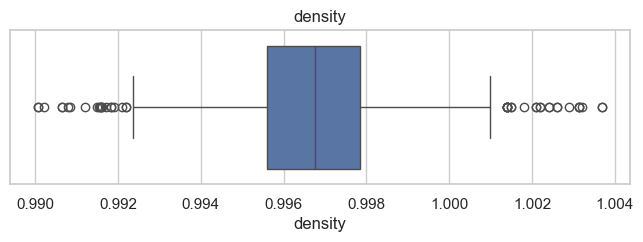

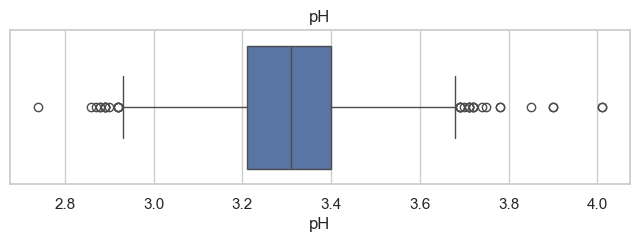

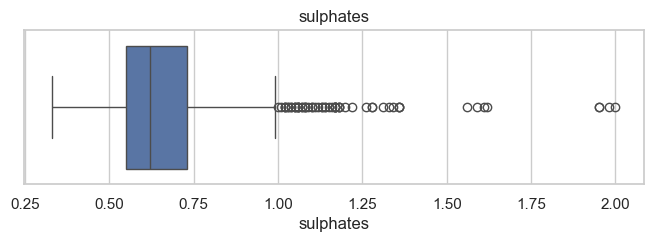

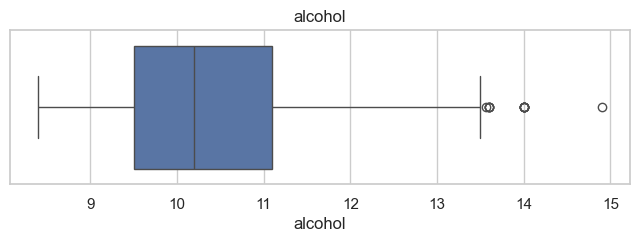

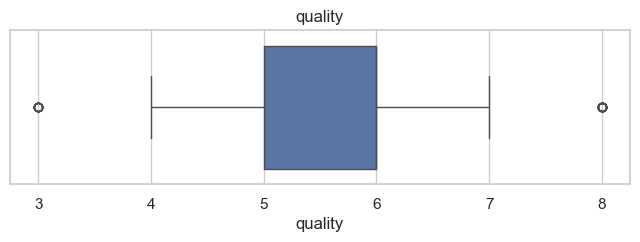

In [14]:
numeric_cols = df.select_dtypes(
    include="number"
).columns

for col in numeric_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()